In [1]:
from typing import Any

import numpy as np
import pandas as pd
import torch
import networkx as nx
import random


np.random.seed(42)
torch.manual_seed(42)
random.seed(42)
torch.mps.seed()

In [2]:
G = nx.Graph()

In [3]:
blue, orange, green = "#1f77b4", "#ff7f0e", "#2ca02c"
G.add_nodes_from([
    (1,{'color':blue}),
    (2,{'color':orange}),
    (3,{'color':blue}),
    (4,{'color':green}),
])

In [4]:

edges = [(1,2),(2,3),(1,3),(3,4)]
G.add_edges_from(edges)

In [5]:
A = np.asarray(nx.adjacency_matrix(G).todense())

In [6]:
A

array([[0, 1, 1, 0],
       [1, 0, 1, 0],
       [1, 1, 0, 1],
       [0, 0, 1, 0]])

In [7]:
color_map = nx.get_node_attributes(G,'color').values()

In [8]:
color_map

dict_values(['#1f77b4', '#ff7f0e', '#1f77b4', '#2ca02c'])

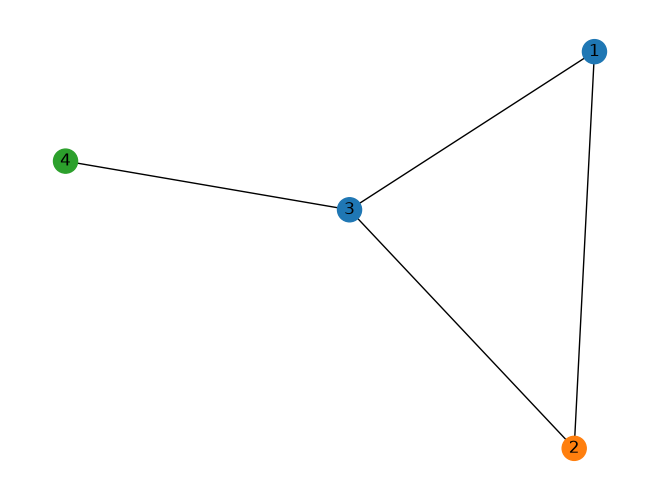

In [9]:
nx.draw(G,with_labels=True, node_color=color_map)

In [10]:
def build_one_hot_color_representation(G,nx,mapping_dict):
    one_hot_indices = np.array([mapping_dict[v] for v in nx.get_node_attributes(G,'color').values()])
    one_hot_encodings = np.zeros((len(one_hot_indices),len(mapping_dict)))
    one_hot_encodings[np.arange(len(one_hot_encodings)),one_hot_indices]=1
    return one_hot_encodings

In [11]:
mapping_dict = {blue:0,orange:1,green:2}

In [12]:
encodings = build_one_hot_color_representation(G,nx,mapping_dict)

In [13]:
encodings

array([[1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.]])

In [14]:
encodings

array([[1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.]])

In [15]:
adjacency_list = []
for i in range(len(encodings)):
    for j in range(len(encodings)-1):
        if encodings[i][j]:
            adjacency_list.append((i,j))

In [16]:
adjacency_list

[(0, 0), (1, 1), (2, 0), (3, 2)]

In [17]:
adjacency_list = [(i, j) for i in range(len(encodings)) for j in range(len(encodings)-1) if encodings[i][j]]

In [18]:
adjacency_list

[(0, 0), (1, 1), (2, 0), (3, 2)]

In [19]:
encodings.shape

(4, 3)

In [20]:
in_features,out_features = encodings.shape[1],6

In [21]:
W1=np.random.rand(in_features,out_features)

In [22]:
W2 = np.random.rand(in_features,out_features)

In [23]:
W2.shape

(3, 6)

In [24]:
h = np.dot(encodings,W1)+np.dot(np.dot(A,encodings),W2)
h

array([[0.86584039, 2.17119255, 1.5786311 , 1.82475761, 1.74460126,
        0.48053535],
       [0.58117253, 1.21187339, 1.48907138, 0.61765726, 1.64703472,
        0.63227739],
       [1.55007341, 2.61134505, 1.70066933, 2.31993452, 1.77898978,
        1.38985575],
       [0.81152668, 0.6537283 , 0.88455922, 0.41281226, 1.06361484,
        0.95570009]])

In [25]:
h = np.dot(encodings,W1)+np.dot(np.dot(A,encodings),W2)

In [26]:
h

array([[0.86584039, 2.17119255, 1.5786311 , 1.82475761, 1.74460126,
        0.48053535],
       [0.58117253, 1.21187339, 1.48907138, 0.61765726, 1.64703472,
        0.63227739],
       [1.55007341, 2.61134505, 1.70066933, 2.31993452, 1.77898978,
        1.38985575],
       [0.81152668, 0.6537283 , 0.88455922, 0.41281226, 1.06361484,
        0.95570009]])

In [27]:
import torch.nn.functional as F
from torch import nn


In [28]:
torch.manual_seed(42)
class ConvolutionLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels

        self.W2 = nn.Parameter(
            torch.rand((in_channels, out_channels), dtype=torch.float32)
        )
        self.W1 = nn.Parameter(
            torch.rand((in_channels, out_channels), dtype=torch.float32)
        )

        self.bias = nn.Parameter(torch.zeros(out_channels, dtype=torch.float32))

    def forward(self, X, A):
        potential_msgs = torch.mm(X, self.W2)
        propagated_msgs = torch.mm(A, potential_msgs)
        root_update = torch.mm(X, self.W1)
        output = propagated_msgs + root_update + self.bias
        return output



In [29]:
layer = ConvolutionLayer(3,10)

In [30]:
encodings.shape

(4, 3)

In [31]:
layer(torch.tensor(encodings,dtype=torch.float32),torch.tensor(A,dtype=torch.float32)).shape

torch.Size([4, 10])

In [32]:
layer

ConvolutionLayer()

## Graph Neural Network dummy data

In [33]:
node_network = nn.Sequential()
input_features = 3 #todo

In [34]:
node_network.add_module('conv1',ConvolutionLayer(input_features,32))

In [ ]:
class BasicGraphNetwork(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.conv1 = ConvolutionLayer(in_features,32)
        self.conv2 = ConvolutionLayer(32,32)
        self.fc_1 = torch.nn.Linear(32, 16)
        self.out_layer = torch.nn.Linear(16, 2)

    def forward(self, X, A, batch_mat):
        x = self.conv1(X, A).clamp(0)
        x = self.conv2(x, A).clamp(0)
        output = global_sum_pool(x, batch_mat)
        output = self.fc_1(output)
        output = self.out_layer(output)
        return F.softmax(output, dim=1)


In [ ]:
def global_sum_pool(x,batch_mat):
    if batch_mat is None or batch_mat.dim()==1:
        return torch.sum(x,dim=0).unsqueeze(0)
    else:
        return torch.mm(batch_mat,x)

### Adding data

In [ ]:
G2 = nx.Graph()
G2.add_nodes_from([
    (1,{'color':green}),
    (2,{'color':green}),
    (3,{'color':orange}),
    (4,{'color':orange}),
    (5,{'color':blue}),

])

In [ ]:
adjacency_list2 = [(2, 3),(3, 4),(3, 1),(5, 1)]
G2.add_edges_from(adjacency_list2)


In [ ]:
G3 = nx.Graph()
G3.add_nodes_from([
    (1,{'color':orange}),
    (2,{'color':orange}),
    (3,{'color':green}),
    (4,{'color':green}),
    (5,{'color':blue}),
    (6,{'color':orange}),

])
adjacency_list3 = [(2,3), (3,4), (3,1), (5,1), (2,5), (6,1)]
G3.add_edges_from(adjacency_list3)

In [ ]:
G4 = nx.Graph()
G4.add_nodes_from([
    (1,{'color':blue}),
    (2,{'color':blue}),
    (3,{'color':green}),


])
adjacency_list4 = [(1,2),(2,3)]
G4.add_edges_from(adjacency_list4)

In [ ]:
mapping_dict

### Adding helper functions

In [ ]:
def get_graph_dict(nx,G,mapping_dict):
    A = torch.from_numpy(np.asarray(nx.adjacency_matrix(G).todense())).float()
    X=torch.from_numpy(build_one_hot_color_representation(G,nx,mapping_dict)).float()
    y = torch.tensor([[1,0]]).float()
    graph_dict = {'A':A,'X':X,'y':y,'batch_mat':None}
    return graph_dict




In [ ]:
type(torch.from_numpy(np.asarray(nx.adjacency_matrix(G).todense())).float())


In [ ]:
A = torch.from_numpy(np.asarray(nx.adjacency_matrix(G).todense())).float()

In [ ]:
X=torch.from_numpy(build_one_hot_color_representation(G,nx,mapping_dict)).float()

In [ ]:
y = torch.tensor([[1,0]]).float()

In [ ]:
graph_dict = {'A':A,'X':X,'y':y,'batch_mat':None}

In [ ]:
def get_batch_tensor(graph_sizes):
    starts = [sum(graph_sizes[:i]) for i in range(len(graph_sizes))]
    stops = [graph_sizes[i]+graph_sizes[i] for i in range(len(graph_sizes))]
    total_length = sum(graph_sizes)
    batch_size= len(graph_sizes)
    batch_mat = torch.zeros([batch_size,total_length]).float()
    for i,s1_s2 in enumerate(zip(starts,stops)):
        start,stop  = s1_s2[0],s1_s2[1]
        batch_mat[i,start:stop]=1
    return batch_mat

### Data Loader

In [ ]:
# batch is a list of dictionaries each containing representation and label of a graph
def collate_graphs(batch):
    adj_matrix = [graph['A'] for graph in batch]
    sizes = [A.size(0) for A in adj_matrix]
    total_sizes = sum(sizes)

    batch_mat = get_batch_tensor(sizes) # creating batch matrix

    # combining feature matrices
    feature_matrix = torch.cat([graph['X'] for graph in batch], dim=0)

    # combining labels

    labels = torch.cat([graph['y'] for graph in batch],dim=0)

    # combining adjacency matrices
    batch_adj = torch.zeros([total_sizes,total_sizes],dtype=torch.float32)

    accum = 0

    for adj in adj_matrix:
        print(adj.shape)
        g_size = adj.shape[0]
        print(g_size)
        print(batch_adj.shape)
        batch_adj[accum:accum+g_size,accum+g_size]=adj
        accum = accum+g_size

    representation_and_label = {
        'A': batch_adj,
        'X': feature_matrix,
        'y': labels,
        'batch_mat': batch_mat
    }
    return representation_and_label

In [ ]:
def collate_graphs(batch):
    adj_mats = [graph["A"] for graph in batch]
    sizes = [A.size(0) for A in adj_mats]
    tot_size = sum(sizes)
    # create batch matrix
    batch_mat = get_batch_tensor(sizes)
    # combine feature matrices
    feat_mats = torch.cat([graph["X"] for graph in batch], dim=0)
    # combine labels
    labels = torch.cat([graph["y"] for graph in batch], dim=0)
    # combine adjacency matrices
    batch_adj = torch.zeros([tot_size, tot_size], dtype=torch.float32)
    accum = 0
    for adj in adj_mats:
        g_size = adj.shape[0]
        batch_adj[accum : accum + g_size, accum : accum + g_size] = adj
        accum = accum + g_size
    repr_and_label = {"A": batch_adj, "X": feat_mats, "y": labels, "batch": batch_mat}

    return repr_and_label

In [ ]:
def get_graph_dict(G, mapping_dict):
    # build dictionary representation of graph G
    A = torch.from_numpy(np.asarray(nx.adjacency_matrix(G).todense())).float()
    # build_graph_color_label_representation() was introduced with the first example graph
    X = torch.from_numpy(
        build_one_hot_color_representation(G,nx, mapping_dict)
    ).float()
    # kludge since there is not specific task for this example
    y = torch.tensor([[1, 0]]).float()
    return {"A": A, "X": X, "y": y, "batch": None}


# building 4 graphs to treat as a dataset

blue, orange, green = "#1f77b4", "#ff7f0e", "#2ca02c"
mapping_dict = {green: 0, blue: 1, orange: 2}

G1 = nx.Graph()
G1.add_nodes_from(
    [
        (1, {"color": blue}),
        (2, {"color": orange}),
        (3, {"color": blue}),
        (4, {"color": green}),
    ]
)
G1.add_edges_from([(1, 2), (2, 3), (1, 3), (3, 4)])
G2 = nx.Graph()
G2.add_nodes_from(
    [
        (1, {"color": green}),
        (2, {"color": green}),
        (3, {"color": orange}),
        (4, {"color": orange}),
        (5, {"color": blue}),
    ]
)
G2.add_edges_from([(2, 3), (3, 4), (3, 1), (5, 1)])
G3 = nx.Graph()
G3.add_nodes_from(
    [
        (1, {"color": orange}),
        (2, {"color": orange}),
        (3, {"color": green}),
        (4, {"color": green}),
        (5, {"color": blue}),
        (6, {"color": orange}),
    ]
)
G3.add_edges_from([(2, 3), (3, 4), (3, 1), (5, 1), (2, 5), (6, 1)])
G4 = nx.Graph()
G4.add_nodes_from([(1, {"color": blue}), (2, {"color": blue}), (3, {"color": green})])
G4.add_edges_from([(1, 2), (2, 3)])
graph_list = [get_graph_dict(graph, mapping_dict) for graph in [G1, G2, G3, G4]]

In [ ]:
graph_list

In [ ]:
#graph_list=[get_graph_dict(nx,graphs,mapping_dict) for graphs in [G,G2,G3,G4]]

In [ ]:
graph_list[0]

In [ ]:
class ExampleDataSet(torch.utils.data.Dataset):
    def __init__(self,graphs):
        self.graph_list = graphs

    def __len__(self):
        return len(self.graph_list)

    def __getitem__(self, index):
        return self.graph_list[index]

In [ ]:
ds = ExampleDataSet(graph_list)

In [ ]:
ds[0]

In [ ]:
from torch.utils.data import DataLoader
loader = DataLoader(
    ds,batch_size=2,collate_fn=collate_graphs,
    shuffle=False
)

In [ ]:
next(iter(loader))

In [ ]:
input_features = 3

In [ ]:
model = BasicGraphNetwork(input_features)

In [ ]:
model

In [ ]:
batch_results = []
for b in loader:
    batch_results.append(
        model(b['X'],b['A'],b['batch']).detach()
    )

In [ ]:
batch_results = []

for b in loader:
    batch_results.append(model(b["X"], b["A"], b["batch"]).detach())



In [ ]:
batch_results

In [ ]:
from torch_geometric.nn import GCNConv


class GNNEncoder(nn.Module):
    def __init__(self, in_channels:int,out_channels:int):
        super().__init__()
        self.conv1 = GCNConv(in_channels,16)
        self.conv2 = GCNConv(16,out_channels)

    def forward(self,data):
        x,edge_index = data.x,data.edge_index
        x = self.conv1(x,edge_index).relu() # GCNConv see assignment to see how message passing is done
        x = self.conv2(x,edge_index)
        return x # Node embeddings




## Molecule DataSet

In [2]:
import torch
import torch.nn.functional as F
import torch_geometric
from torch_geometric.datasets import QM9

/Users/deven/.virtualenvs/Machine_Learning_Algorithms/lib/python3.14/site-packages/torch/jit/_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [3]:
data = QM9('./')

Extracting ./raw/qm9.zip
Processing...
100%|██████████| 133885/133885 [00:21<00:00, 6323.21it/s]
Done!


In [17]:
ds = data[0]

In [18]:
len(data)

130831

In [19]:
ds

Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], z=[5], smiles='[H]C([H])([H])[H]', name='gdb_1', idx=[1])

In [20]:
ds.z

tensor([6, 1, 1, 1, 1])

In [21]:
ds.x

tensor([[0., 1., 0., 0., 0., 6., 0., 0., 0., 0., 4.],
        [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

In [22]:
ds.edge_index

tensor([[0, 0, 0, 0, 1, 2, 3, 4],
        [1, 2, 3, 4, 0, 0, 0, 0]])

In [23]:
ds.new_attribute = torch.tensor([1,2,3])

In [24]:
ds

Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], z=[5], smiles='[H]C([H])([H])[H]', name='gdb_1', idx=[1], new_attribute=[3])

In [25]:
device = "mps"

In [26]:
ds.to(device)

Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], z=[5], smiles='[H]C([H])([H])[H]', name='gdb_1', idx=[1], new_attribute=[3])

In [27]:
ds.new_attribute.device

device(type='mps', index=0)

In [28]:
ds.x.device

device(type='mps', index=0)

 x should contain node features, edge_attr should contain edge features, edge_index should include an edge
list, and y should contain labels.

In [29]:
ds.y

tensor([[    0.0000,    13.2100,   -10.5499,     3.1865,    13.7363,    35.3641,
             1.2177, -1101.4878, -1101.4098, -1101.3840, -1102.0229,     6.4690,
           -17.1722,   -17.2868,   -17.3897,   -16.1519,   157.7118,   157.7100,
           157.7070]], device='mps:0')

In [30]:
ds.edge_attrs()

['edge_attr', 'edge_index']

In [31]:
ds.edge_attr

tensor([[1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.]], device='mps:0')

In [32]:
ds.edge_index

tensor([[0, 0, 0, 0, 1, 2, 3, 4],
        [1, 2, 3, 4, 0, 0, 0, 0]], device='mps:0')

## Implementing GNN using NNCONV

In [34]:
from torch_geometric.nn import NNConv,global_add_pool

In [90]:
from torch_geometric.data import Data,DataLoader
from torch import nn

class GNN(nn.Module):
    def __init__(self, num_node_features,num_edge_features):
        super().__init__()
        conv1_net = nn.Sequential(
            nn.Linear(num_edge_features,32),
            nn.ReLU(),
            nn.Linear(32,num_node_features*32)
        )
        conv2_net = nn.Sequential(
            nn.Linear(num_edge_features,32),
            nn.ReLU(),
            nn.Linear(32,32*16)
        )
        self.conv1 = NNConv(num_node_features,32,conv1_net)
        self.conv2 = NNConv(32,16,conv2_net)

        self.fc1 = nn.Linear(16,32)
        self.fc2 = nn.Linear(32,1)

    def forward(self,data):
        batch,edge_index,x,edge_attribute = data.batch,data.edge_index,data.x,data.edge_attr

        out = F.relu(self.conv1(x,edge_index,edge_attribute))
        out = F.relu(self.conv2(out,edge_index,edge_attribute))
        out = global_add_pool(out,batch)
        out = F.relu(self.fc1(out))
        out = self.fc2(out)
        return out



In [91]:
from torch.utils.data import random_split

In [92]:
ds

Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], z=[5], smiles='[H]C([H])([H])[H]', name='gdb_1', idx=[1], new_attribute=[3])

In [93]:
torch.manual_seed(42)
train_ds,val_ds,test_ds = random_split(data,[110000,10831,10000])

In [94]:
len(train_ds)+len(val_ds)+len(test_ds)==len(data)

True

In [95]:
type(train_ds)

torch.utils.data.dataset.Subset

In [96]:
train_loader = DataLoader(train_ds,batch_size=32,shuffle=True)
val_loader = DataLoader(val_ds,batch_size=32,shuffle=False)
test_loader = DataLoader(test_ds,batch_size=32,shuffle=False)

/var/folders/3y/b0yw6xl90r5ddg0z2yylh2380000gn/T/ipykernel_10543/4088555508.py:1: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_ds,batch_size=32,shuffle=True)
/var/folders/3y/b0yw6xl90r5ddg0z2yylh2380000gn/T/ipykernel_10543/4088555508.py:2: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader = DataLoader(val_ds,batch_size=32,shuffle=True)
/var/folders/3y/b0yw6xl90r5ddg0z2yylh2380000gn/T/ipykernel_10543/4088555508.py:3: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(test_ds,batch_size=32,shuffle=True)


In [97]:
next(iter(train_loader))

DataBatch(x=[591, 11], edge_index=[2, 1222], edge_attr=[1222, 4], y=[32, 19], pos=[591, 3], z=[591], smiles=[32], name=[32], idx=[32], batch=[591], ptr=[33])

In [98]:
for batch in train_loader:
    print(batch)
    break

DataBatch(x=[575, 11], edge_index=[2, 1188], edge_attr=[1188, 4], y=[32, 19], pos=[575, 3], z=[575], smiles=[32], name=[32], idx=[32], batch=[575], ptr=[33])


In [99]:
nodes,edges = 11,4
model = GNN(nodes,edges)
model = model.to(device)

In [100]:
optimizer = torch.optim.Adam(model.parameters(),lr=.001)
epochs = 4
target_index = 1

In [101]:
test1 = next(iter(train_loader)).to(device)
model(test1)

tensor([[ 0.1837],
        [-0.6409],
        [ 0.2695],
        [ 1.1634],
        [ 0.4861],
        [-1.1044],
        [-0.3430],
        [ 0.6324],
        [-1.1107],
        [ 0.4413],
        [-1.2907],
        [ 1.5974],
        [ 0.9479],
        [-0.1683],
        [-0.4586],
        [-0.9174],
        [ 1.2606],
        [-0.3879],
        [-0.0906],
        [ 0.6285],
        [ 0.3847],
        [-1.3377],
        [-1.4403],
        [ 0.5253],
        [-1.0213],
        [-0.6968],
        [ 1.2281],
        [ 0.3784],
        [-0.0549],
        [-1.5067],
        [-0.4525],
        [-0.6267]], device='mps:0', grad_fn=<LinearBackward0>)

In [102]:
ds.y

tensor([[    0.0000,    13.2100,   -10.5499,     3.1865,    13.7363,    35.3641,
             1.2177, -1101.4878, -1101.4098, -1101.3840, -1102.0229,     6.4690,
           -17.1722,   -17.2868,   -17.3897,   -16.1519,   157.7118,   157.7100,
           157.7070]], device='mps:0')

In [131]:
from tqdm import tqdm
import torchmetrics

metric_collection = torchmetrics.MetricCollection([
    torchmetrics.regression.MeanSquaredError(),
    torchmetrics.regression.R2Score()
]).to(device)

train_metrics = metric_collection.clone(prefix="train_")
val_metrics = metric_collection.clone(prefix="val_")
# Create a checkpoint dictionary containing everything


for epoch in range(epochs):
    epoch_loss,total_graphs = 0,0
    model.train()
    train_metrics.reset()



    for batch in tqdm(train_loader,desc=f"Training at {epoch}"):

        # Forward Pass
        optimizer.zero_grad()
        batch.to(device)
        output = model(batch)
        loss = F.mse_loss(output,batch.y[:,target_index].unsqueeze(1))

        # Metric usage
        train_metrics.update(output,batch.y[:,target_index].unsqueeze(1))
        #Backward Pass
        loss.backward()

        optimizer.step()

        epoch_loss+=loss.item()
        total_graphs+=batch.num_graphs
    epoch_train_results = train_metrics.compute()
    avg_loss = epoch_loss/total_graphs

    ## Evaluation Loop
    val_loss,val_graphs = 0,0
    model.eval()
    val_metrics.reset()
    with torch.no_grad():
        for batch in val_loader:
            batch.to(device)

            #print("In validation loop:")
            # Forward
            output = model(batch)
            #print(output)
            val_metrics.update(output,batch.y[:,target_index].unsqueeze(1))
            loss = F.mse_loss(output,batch.y[:,target_index].unsqueeze(1))
            val_loss +=loss.item()
            val_graphs += batch.num_graphs
    epoch_val_results = val_metrics.compute()
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_metrics_state': train_metrics.state_dict(),
        'val_metrics_state': val_metrics.state_dict()
    }

    # Save the file to disk
    torch.save(checkpoint, f"checkpoint{epoch+1}.pt")
    avg_val_loss = val_loss/val_graphs

    print(f"Epoch {epoch+1} Summary:")
    print(f"  Losses -> Train Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"  Train Metrics -> MSE: {epoch_train_results['train_MeanSquaredError']:.4f} | R2: {epoch_train_results['train_R2Score']:.4f}")
    print(f"  Val Metrics   -> MSE: {epoch_val_results['val_MeanSquaredError']:.4f} | R2: {epoch_val_results['val_R2Score']:.4f}")











Training at 0: 100%|██████████| 3438/3438 [00:29<00:00, 115.00it/s]


Epoch 1 Summary:
  Losses -> Train Loss: 0.0430 | Val Loss: 0.0319
  Train Metrics -> MSE: 1.3772 | R2: 0.9794
  Val Metrics   -> MSE: 1.0195 | R2: 0.9847


Training at 1: 100%|██████████| 3438/3438 [00:31<00:00, 109.34it/s]


Epoch 2 Summary:
  Losses -> Train Loss: 0.0418 | Val Loss: 0.0529
  Train Metrics -> MSE: 1.3358 | R2: 0.9801
  Val Metrics   -> MSE: 1.6892 | R2: 0.9747


Training at 2: 100%|██████████| 3438/3438 [00:31<00:00, 107.82it/s]


Epoch 3 Summary:
  Losses -> Train Loss: 0.0418 | Val Loss: 0.0577
  Train Metrics -> MSE: 1.3362 | R2: 0.9801
  Val Metrics   -> MSE: 1.8434 | R2: 0.9724


Training at 3: 100%|██████████| 3438/3438 [00:30<00:00, 112.64it/s]


Epoch 4 Summary:
  Losses -> Train Loss: 0.0402 | Val Loss: 0.0312
  Train Metrics -> MSE: 1.2864 | R2: 0.9808
  Val Metrics   -> MSE: 0.9988 | R2: 0.9850


In [132]:
checkpoint = torch.load("checkpoint3.pt")
model.load_state_dict(checkpoint['model_state_dict'])
train_metrics.load_state_dict(checkpoint['train_metrics_state'])

<All keys matched successfully>

In [137]:
epoch_results=train_metrics.compute()

In [138]:
pd.DataFrame([{k:v.item() for (k,v) in epoch_results.items()}])

,train_MeanSquaredError,train_R2Score
0,1.286435,0.980793


## Checkpoint to resume training

In [ ]:

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# Load the metric states back into the TorchMetrics objects
train_metrics.load_state_dict(checkpoint['train_metrics_state'])
val_metrics.load_state_dict(checkpoint['val_metrics_state'])

# 4. Extract the next starting epoch
start_epoch = checkpoint['epoch'] + 1

### Prediction,

In [115]:
import torch
import torchmetrics

# 1. Initialize your evaluation metrics on the correct device
test_metrics = torchmetrics.MetricCollection([
    torchmetrics.regression.MeanSquaredError(),
    torchmetrics.regression.R2Score(),
    torchmetrics.regression.MeanAbsoluteError()
]).to(device)

model.eval()
test_metrics.reset() # Clear out any previous evaluations

with torch.inference_mode():
    for batch in test_loader:
        batch = batch.to(device) # Keep data fully on GPU
        output = model(batch)
        target = batch.y[:, target_index].unsqueeze(1)

        # Accumulate metrics fully on the GPU without leaving the device
        test_metrics.update(output, target)

# 2. Compute final scores over the entire test dataset (returns a dictionary)
test_results = test_metrics.compute()

# Print metrics directly
print("--- Test Set Performance ---")
print(f"MSE: {test_results['MeanSquaredError'].item():.4f}")
print(f"MAE: {test_results['MeanAbsoluteError'].item():.4f}")
print(f"R2 Score: {test_results['R2Score'].item():.4f}")


--- Test Set Performance ---
MSE: 1.5223
MAE: 0.8387
R2 Score: 0.9766


In [106]:
real

array([77.79, 81.15, 75.54, ..., 71.13, 72.34, 66.6 ],
      shape=(10000,), dtype=float32)

In [107]:
predictions

array([[78.31673 ],
       [81.05013 ],
       [74.74689 ],
       ...,
       [70.455025],
       [72.81654 ],
       [67.892914]], shape=(10000, 1), dtype=float32)

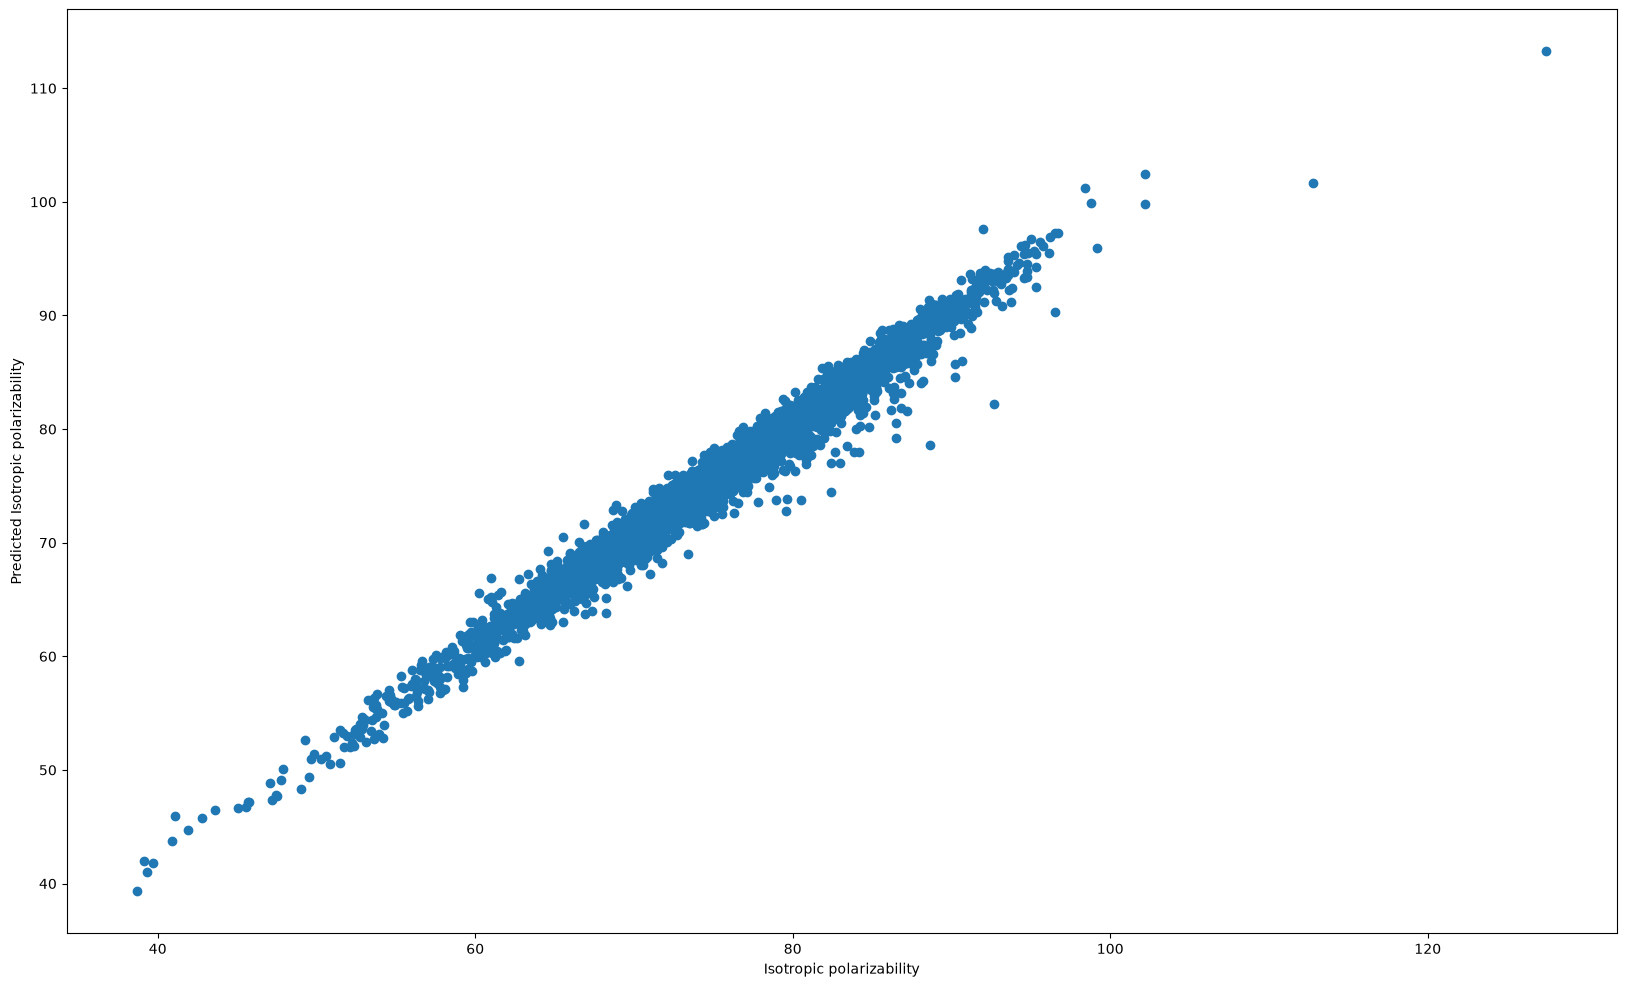

In [110]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,12))
plt.scatter(real[:5000],predictions[:5000])
plt.xlabel('Isotropic polarizability')
plt.ylabel('Predicted Isotropic polarizability')
plt.show()

In [111]:
import torchmetrics

In [112]:
mse_metric = torchmetrics.regression.MeanSquaredError()
for _ in range(3):
    x = torch.randn(10,1)
    y = torch.randn(10,1)

    mse_metric.update(x,y)
total_mse = mse_metric.compute()
print(f"total mse={total_mse.item()}")
mse_metric.reset()


total mse=1.4116785526275635


In [119]:
clean_results = {k: v.item() for k, v in test_results.items()}


In [120]:
df = pd.DataFrame([clean_results])

In [121]:
df

,MeanSquaredError,R2Score,MeanAbsoluteError
0,1.5223,0.976626,0.83866
